# Exercise sheet 2: Supervised Regression

In [1]:
#| label: import
# Consider the following libraries for this exercise sheet:

# general
import numpy as np
import pandas as pd
import math
# plots
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
from sklearn.metrics import mean_absolute_error

## Exercise 1: HRO

Throughout the lecture, we will frequently use the Python package `sklearn`, and its descendants, providing an integrated ecosystem for all common machine learning tasks. Let’s recap the HRO
principle and see how it is reflected in `sklearn`.<br>
An overview of the most important objects andtheir usage, illustrated with numerous examples, can be found at __[https://scikit-learn.org/stable/index.html](https://scikit-learn.org/stable/index.html)__.

> a) How are the key concepts (i.e., hypothesis space, risk and optimization) you learned about in the lecture videos
implemented?

> **\# Enter your answer here:**
#### Hypothesis Space (Không gian giả thuyết)
Trong scikit-learn, không gian giả thuyết được biểu diễn thông qua các lớp mô hình
(estimator) như `LinearRegression`, `DecisionTreeRegressor`, `SVR`, …
Mỗi mô hình định nghĩa một tập các hàm dự đoán có thể học được.
Các hyperparameter (ví dụ: `max_depth`, `min_samples_leaf`) dùng để kiểm soát
độ phức tạp của không gian giả thuy#ết.

### Risk (Hàm rủi ro / hàm m  ất mát)
Risk được biểu diễn thông qua các hàm mất mát (loss functions) và scoring functions.
Trong bài toán hồi quy, các hàm thường gặp là Mean Squared Error (MSE),
Mean Absolute Error (MAE), hoặc   R² score.
Các hàm này dùng để đánh giá mức độ sai lệch giữa giá trị dự đoán và gi  á #trị thực.

### Optimization   (Tối ưu hóa)
Quá trình tối ưu hóa được thực hiện khi gọi phương thức `fit(X, y)`.
Tùy từng mô hình, scikit-learn sử dụng các thuật toán tối ưu khác nhau:
- Linear Regression: nghiệm giải tích
- Decision Tree: thuật toán greedy để tìm điểm chia tốt nhất
- Các mô hình khác: gradient-based optimization
Người dùng không cần cài đặt thuật toán tối ưu thủ công.



> b) Have a look at `sklearn.datasets import load_iris`. What attributes does this
object store?

In [2]:
# Enter your code here:
from sklearn.datasets import load_iris

iris = load_iris()

# Xem các thuộc tính có trong đối tượng
iris.keys()
# Các thuộc tính quan trọng
print(iris.data ) # ma trận đặc trưng



[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [3]:
print(iris.target) # nhãn lớp

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
print(iris.feature_names) #tên đặc trưng

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
print(iris.target_names) # tên cácc lớp

['setosa' 'versicolor' 'virginica']


In [6]:
print(iris.DESCR) # mô tả toàn bộ dữ liệu

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

> c) Instantiate a regression tree learner (`DecisionTreeRegressor`). What are the different settings for this learner?

<div class="alert alert-block alert-info">
<b>Hint:</b> Import the specific module and use <code>get_params()</code> to see all available settings.
</div>

In [7]:
# Enter your code here:
from sklearn.tree import DecisionTreeRegressor

# Khởi tạo mô hình
reg = DecisionTreeRegressor()

# Xem toàn bộ tham số của mô hình
reg.get_params()


{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

In [9]:
# Ví dụ khởi tạo với một số tham số phổ biến
reg_custom = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


## Exercise 4: Predicting `abalone`

We want to predict the age of an abalone using its longest shell measurement and its weight. <br>

In [14]:
import pandas as pd
url = 'abalone.csv'
abalone = pd.read_csv(url, sep=",",
names=["sex", "longest_shell", "diameter", "height", "whole_weight",
"shucked_weight", "visceral_weight", "shell_weight", "rings"])
abalone = abalone[["longest_shell", "whole_weight", "rings"]]

> a) Plot `LongestShell` and `WholeWeight` on the x- and y-axis, respectively, and color points according to `Rings`.

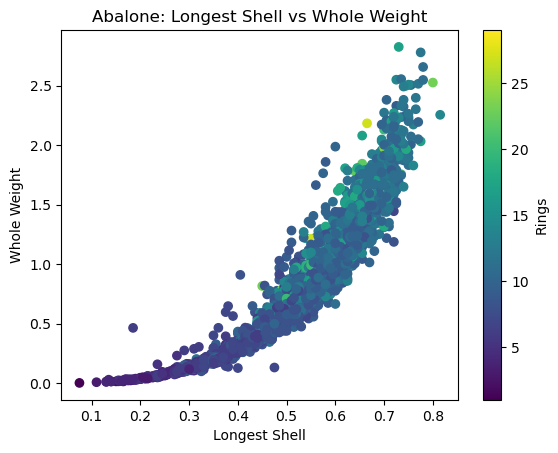

In [16]:
import matplotlib.pyplot as plt
# Enter your code here:
plt.figure()
scatter = plt.scatter(
    abalone["longest_shell"],
    abalone["whole_weight"],
    c=abalone["rings"]
)
plt.xlabel("Longest Shell")
plt.ylabel("Whole Weight")
plt.colorbar(scatter, label="Rings")
plt.title("Abalone: Longest Shell vs Whole Weight")
plt.show()


> b) Using `sklearn`, fit a linear regression model to the data.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
# Enter your code here:
X = abalone[["longest_shell", "whole_weight"]]
y = abalone["rings"]

model = LinearRegression()
model.fit(X, y)


LinearRegression()

> c) Compare the fitted and observed targets visually.

<div class="alert alert-block alert-info">
<b>Python:</b> use <code>import matplotlib.pyplot as plt</code>.
</div>

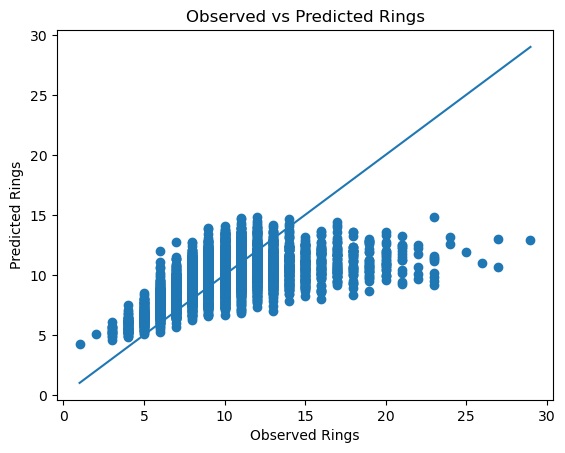

In [19]:
# Enter your code here:
y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Observed Rings")
plt.ylabel("Predicted Rings")
plt.title("Observed vs Predicted Rings")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()


> d) Assess the model’s training loss in terms of MAE.

<div class="alert alert-block alert-info">
<b>Python Hint:</b> The MAE metric is retrieved by calling <code>from sklearn.metrics import mean_absolute_error</code>.
</div>

In [20]:
# Enter your code here:
mae = mean_absolute_error(y, y_pred)
print("Training MAE:", mae)


Training MAE: 1.9506602873468448


![abalone.JPG](attachment:abalone.JPG)

__[https://en.wikipedia.org/wiki/Abalone#/media/File:LivingAbalone.JPG](https://en.wikipedia.org/wiki/Abalone#/media/File:LivingAbalone.JPG)__